In [2]:
pwd


'/scratch/user/s4906996/Cellpose SAM'

In [5]:
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from skimage.color import label2rgb
import csv


base_dir = Path.cwd()
print("Base dir:", base_dir)

sam_dir = base_dir / "cellpose_sam_results"
manual_dir = base_dir / "manual_segmentation_masks"
out_csv = base_dir / "sam_vs_manual_comparison.csv"

print("SAM dir exists:", sam_dir.exists(), sam_dir)
print("Manual dir exists:", manual_dir.exists(), manual_dir)

Base dir: /scratch/user/s4906996/Cellpose SAM
SAM dir exists: True /scratch/user/s4906996/Cellpose SAM/cellpose_sam_results
Manual dir exists: True /scratch/user/s4906996/Cellpose SAM/manual_segmentation_masks


In [6]:
print("\nSAM files:")
for f in sorted(sam_dir.glob("*"))[:20]:
    print(f.name)

print("\nManual files:")
for f in sorted(manual_dir.glob("*"))[:20]:
    print(f.name)


SAM files:
614399S2D20250113_sam_masks.tif
614399S2D20250113_sam_overlay.png
614399s1d120250113_sam_masks.tif
614399s1d120250113_sam_overlay.png
614399s1d20241213_sam_masks.tif
614399s1d20241213_sam_overlay.png
614399s1d20250108_sam_masks.tif
614399s1d20250108_sam_overlay.png
614400s1d20241218_sam_masks.tif
614400s1d20241218_sam_overlay.png
614400s1d20250108_sam_masks.tif
614400s1d20250108_sam_overlay.png
614401s1d20250114_sam_masks.tif
614401s1d20250114_sam_overlay.png
614401s1d20250414_sam_masks.tif
614401s1d20250414_sam_overlay.png
614404s1d20250115_sam_masks.tif
614404s1d20250115_sam_overlay.png
671461s1d20250728_sam_masks.tif
671461s1d20250728_sam_overlay.png

Manual files:
614399S2D20250113 2_mask.tiff
614399s1d120250113 2_mask.tiff
614399s1d20241213 2_mask.tiff
614399s1d20250108 2_mask.tiff
614400s1d20241218 2_mask.tiff
614400s1d20250108 2_mask.tiff
614401s1d20250114 2_mask.tiff
614401s1d20250414 2_mask.tiff
614404s1d20250115 2_mask.tiff
671480s1d20250709 2_mask.tiff
671481s1d2

In [9]:
sam_fp = sam_dir / "614399s1d20241213_sam_masks.tif"
manual_fp = manual_dir / "614399s1d20241213 2_mask.tiff"

print("SAM exists:", sam_fp.exists(), sam_fp.name)
print("Manual exists:", manual_fp.exists(), manual_fp.name)

SAM exists: True 614399s1d20241213_sam_masks.tif
Manual exists: True 614399s1d20241213 2_mask.tiff


In [11]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import label2rgb

sam_fp = sam_dir / "614399s1d20241213_sam_masks.tif"      # adjust if needed
manual_fp = manual_dir / "614399s1d20241213 2_mask.tiff"   # adjust if needed

sam_masks = tifffile.imread(sam_fp)
manual_masks = tifffile.imread(manual_fp)

print("SAM shape:", sam_masks.shape, sam_masks.dtype, "labels:", int(sam_masks.max()))
print("Manual shape:", manual_masks.shape, manual_masks.dtype, "labels:", int(manual_masks.max()))

SAM shape: (512, 512) uint16 labels: 36
Manual shape: (512, 512) uint16 labels: 33


In [12]:
sam_bin = sam_masks > 0
manual_bin = manual_masks > 0

intersection = np.logical_and(sam_bin, manual_bin).sum()
union = np.logical_or(sam_bin, manual_bin).sum()

pixel_iou = intersection / (union + 1e-8)
pixel_dice = (2 * intersection) / (sam_bin.sum() + manual_bin.sum() + 1e-8)

print("SAM cells:", int(sam_masks.max()))
print("Manual cells:", int(manual_masks.max()))
print("Pixel IoU:", float(pixel_iou))
print("Pixel Dice:", float(pixel_dice))

SAM cells: 36
Manual cells: 33
Pixel IoU: 0.5084616906717793
Pixel Dice: 0.6741459777415236


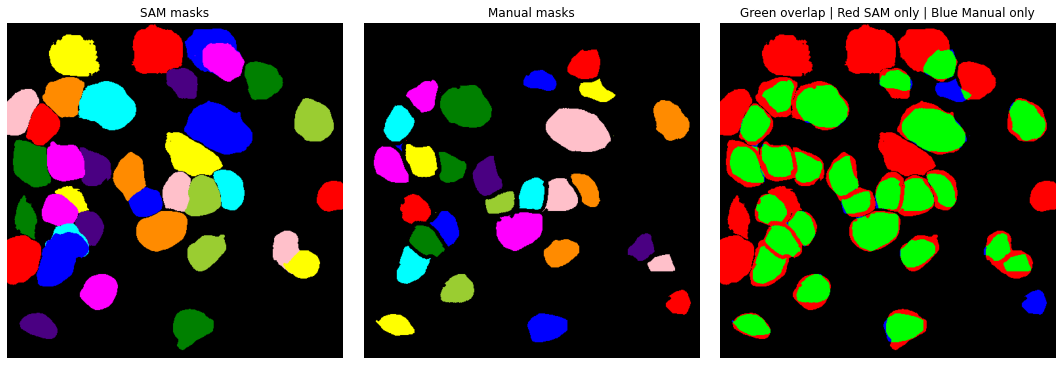

In [13]:
#visualize the overlapp and the masks. 


comparison = np.zeros((*sam_masks.shape, 3), dtype=np.uint8)

comparison[np.logical_and(sam_bin, manual_bin)] = [0, 255, 0]   # overlap = green
comparison[np.logical_and(sam_bin, ~manual_bin)] = [255, 0, 0]  # SAM only = red
comparison[np.logical_and(~sam_bin, manual_bin)] = [0, 0, 255]  # manual only = blue

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(label2rgb(sam_masks, bg_label=0))
plt.title("SAM masks")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(label2rgb(manual_masks, bg_label=0))
plt.title("Manual masks")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(comparison)
plt.title("Green overlap | Red SAM only | Blue Manual only")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# object level matching 

sam_labels = np.unique(sam_masks)
sam_labels = sam_labels[sam_labels > 0]

manual_labels = np.unique(manual_masks)
manual_labels = manual_labels[manual_labels > 0]

iou_matrix = np.zeros((len(sam_labels), len(manual_labels)), dtype=np.float32)

for i, s_lab in enumerate(sam_labels):
    s_mask = sam_masks == s_lab
    for j, m_lab in enumerate(manual_labels):
        m_mask = manual_masks == m_lab
        inter = np.logical_and(s_mask, m_mask).sum()
        uni = np.logical_or(s_mask, m_mask).sum()
        if uni > 0:
            iou_matrix[i, j] = inter / uni

print("IoU matrix shape:", iou_matrix.shape)

IoU matrix shape: (36, 33)


In [15]:
def sam_base(fp):
    name = fp.name
    name = name.replace("_sam_masks.tiff", "")
    name = name.replace("_sam_masks.tif", "")
    return name

def manual_base(fp):
    name = fp.name
    name = name.replace(" 2_mask.tiff", "")
    name = name.replace(" 2_mask.tif", "")
    name = name.replace("_mask.tiff", "")
    name = name.replace("_mask.tif", "")
    return name

manual_map = {manual_base(f): f for f in manual_files}

In [16]:
#IOU and dice function 
def compute_metrics(sam_masks, manual_masks):

    sam_bin = sam_masks > 0
    manual_bin = manual_masks > 0

    intersection = np.logical_and(sam_bin, manual_bin).sum()
    union = np.logical_or(sam_bin, manual_bin).sum()

    iou = intersection / (union + 1e-8)
    dice = (2 * intersection) / (sam_bin.sum() + manual_bin.sum() + 1e-8)

    return iou, dice

In [17]:
results = []

for sam_fp in sam_files:

    base = sam_base(sam_fp)

    if base not in manual_map:
        print("No manual match for:", sam_fp.name)
        continue

    manual_fp = manual_map[base]

    sam_masks = tifffile.imread(sam_fp)
    manual_masks = tifffile.imread(manual_fp)

    iou, dice = compute_metrics(sam_masks, manual_masks)

    sam_cells = int(sam_masks.max())
    manual_cells = int(manual_masks.max())

    print(f"{base} | IoU={iou:.3f} | Dice={dice:.3f}")

    results.append([
        base,
        sam_cells,
        manual_cells,
        float(iou),
        float(dice)
    ])

No manual match for: 614399S2D20250113_sam_masks.tif
No manual match for: 614399s1d120250113_sam_masks.tif
No manual match for: 614399s1d20241213_sam_masks.tif
No manual match for: 614399s1d20250108_sam_masks.tif
No manual match for: 614400s1d20241218_sam_masks.tif
No manual match for: 614400s1d20250108_sam_masks.tif
No manual match for: 614401s1d20250114_sam_masks.tif
No manual match for: 614401s1d20250414_sam_masks.tif
No manual match for: 614404s1d20250115_sam_masks.tif
No manual match for: 671461s1d20250728_sam_masks.tif
No manual match for: 671462s1d20250728_sam_masks.tif
No manual match for: 671463s1d20250701_sam_masks.tif
No manual match for: 671463s2d20250701_sam_masks.tif
No manual match for: 671463s2d20250707_sam_masks.tif
No manual match for: 671480s1d20250325_sam_masks.tif
No manual match for: 671480s1d20250709_sam_masks.tif
No manual match for: 671481s1d20250326_sam_masks.tif
No manual match for: 671482s1d20250218_sam_masks.tif
No manual match for: 671485s1d20250728_sam_ma

In [24]:
import tifffile
import numpy as np

# load raw image corresponding to this mask
raw_fp = base_dir /"resonant"/ "614399s1d20241213.tif"   # change to your raw file

raw = tifffile.imread(raw_fp)

print("Raw shape:", raw.shape)

# resonant data usually (T,H,W)
if raw.ndim == 3:
    im2d = raw.mean(axis=0)
else:
    im2d = raw

# normalize for display
im2d = im2d.astype(np.float32)
im2d = (im2d - im2d.min()) / (im2d.max() - im2d.min() + 1e-8)

print("Display image ready:", im2d.shape)

Raw shape: (512, 512)
Display image ready: (512, 512)


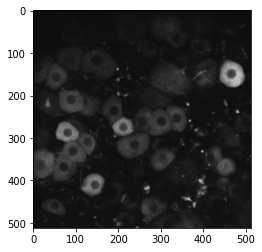

In [26]:
plt.imshow(im2d, cmap="gray")

In [27]:
#trying to create a click based ROI function 
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass
from pathlib import Path
import csv

def find_nearest_nonzero_label(mask, x, y, radius=10):
    h, w = mask.shape

    if 0 <= y < h and 0 <= x < w and mask[y, x] > 0:
        return int(mask[y, x])

    for r in range(1, radius + 1):
        x0, x1 = max(0, x - r), min(w, x + r + 1)
        y0, y1 = max(0, y - r), min(h, y + r + 1)

        patch = mask[y0:y1, x0:x1]
        nonzero = patch[patch > 0]

        if len(nonzero) > 0:
            vals, counts = np.unique(nonzero, return_counts=True)
            return int(vals[np.argmax(counts)])

    return 0


def compute_instance_metrics(sam_roi, manual_roi):
    intersection = np.logical_and(sam_roi, manual_roi).sum()
    union = np.logical_or(sam_roi, manual_roi).sum()

    iou = intersection / (union + 1e-8)
    dice = (2 * intersection) / (sam_roi.sum() + manual_roi.sum() + 1e-8)

    sam_area = int(sam_roi.sum())
    manual_area = int(manual_roi.sum())
    area_difference = abs(sam_area - manual_area)

    sam_centroid = center_of_mass(sam_roi) if sam_area > 0 else (np.nan, np.nan)
    manual_centroid = center_of_mass(manual_roi) if manual_area > 0 else (np.nan, np.nan)

    centroid_distance = np.sqrt(
        (sam_centroid[0] - manual_centroid[0])**2 +
        (sam_centroid[1] - manual_centroid[1])**2
    )

    return {
        "iou": float(iou),
        "dice": float(dice),
        "sam_area": sam_area,
        "manual_area": manual_area,
        "area_difference": area_difference,
        "sam_centroid_y": float(sam_centroid[0]),
        "sam_centroid_x": float(sam_centroid[1]),
        "manual_centroid_y": float(manual_centroid[0]),
        "manual_centroid_x": float(manual_centroid[1]),
        "centroid_distance": float(centroid_distance),
    }


def visualize_instance(im2d, sam_roi, manual_roi, sam_label, manual_label, metrics, save_path=None):
    comparison = np.zeros((*sam_roi.shape, 3), dtype=np.uint8)
    comparison[np.logical_and(sam_roi, manual_roi)] = [0, 255, 0]   # overlap
    comparison[np.logical_and(sam_roi, ~manual_roi)] = [255, 0, 0]  # SAM only
    comparison[np.logical_and(~sam_roi, manual_roi)] = [0, 0, 255]  # manual only

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(im2d, cmap="gray")
    plt.contour(sam_roi.astype(float), levels=[0.5], colors="lime", linewidths=2)
    plt.contour(manual_roi.astype(float), levels=[0.5], colors="red", linewidths=2)
    plt.title(f"Raw\nSAM={sam_label}, Manual={manual_label}")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(sam_roi, cmap="gray")
    plt.title(f"SAM ROI\nlabel={sam_label}")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(manual_roi, cmap="gray")
    plt.title(f"Manual ROI\nlabel={manual_label}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(comparison)
    plt.title(f"IoU={metrics['iou']:.3f}\nDice={metrics['dice']:.3f}")
    plt.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

In [28]:
#creatng a output folder for ROI results. 

roi_eval_dir = base_dir / "roi_instance_evaluation"
roi_eval_dir.mkdir(exist_ok=True)

print("ROI evaluation folder:", roi_eval_dir)

ROI evaluation folder: /scratch/user/s4906996/Cellpose SAM/roi_instance_evaluation


In [ ]:
N_CLICKS = 3

plt.figure(figsize=(8, 8))
plt.imshow(im2d, cmap="gray")
plt.title(f"Click up to {N_CLICKS} ROIs, then close the figure window")
plt.axis("off")

clicked_points = plt.ginput(N_CLICKS, timeout=0)
plt.show()

print("Clicked points:", clicked_points)